# Kapitola 5: Vybraná spojitá rozdělení

## 5.1 Kvantily a kvantilová funkce

**Definice 5.1**  
Kvantilová funkce $F^{-1}(u)$ je definována jako:
$$F^{-1}(u)=\inf\left\{x \in \mathbb{R}: F(x)\geq u \right\}, \quad 0<u<1$$

- $\alpha$-kvantil: $x_\alpha = F^{-1}(\alpha)$
- Medián: $x_{0.5}$
- Dolní kvartil: $x_{0.25}$
- Horní kvartil: $x_{0.75}$

In [1]:
import numpy as np
import plotly.graph_objects as go
from scipy.stats import norm

# Rozsah pravděpodobností
u = np.linspace(0.01, 0.99, 500)

# Kvantilová funkce pro normální rozdělení N(0,1)
x = norm.ppf(u)

# Vyznačení důležitých kvantilů
kvantily = {
    'Dolní kvartil (0.25)': norm.ppf(0.25),
    'Medián (0.5)': norm.ppf(0.5),
    'Horní kvartil (0.75)': norm.ppf(0.75)
}

# Vytvoření grafu s rozmeremi 800x600
fig = go.Figure()
fig.update_layout(width=800, height=600)

# Kvantilová funkce
fig.add_trace(go.Scatter(x=u, y=x, mode='lines', name='Kvantilová funkce'))

# Přidání kvantilů jako body
for label, value in kvantily.items():
    fig.add_trace(go.Scatter(
        x=[float(label.split('(')[-1][:-1])],
        y=[value],
        mode='markers+text',
        name=label,
        text=[label],
        textposition='top center',
        marker=dict(size=8)
    ))

# Popisky a vzhled
fig.update_layout(
    title='Kvantilová funkce pro normální rozdělení N(0,1)',
    xaxis_title='Pravděpodobnost (u)',
    yaxis_title='Kvantil x = F⁻¹(u)',
    template='simple_white'
)
fig.update_xaxes(range=[0, 1])

grid_x = True if np.log10(1) - np.log10(0.01) > 1 else False
# grid pro x a y osy podle rozsahu
fig.update_xaxes(showgrid=grid_x)  # grid pro x osu a y osa má stejný   
fig.update_yaxes(showgrid=grid_x)   
fig.show()

## 5.2 Rovnoměrné rozdělení

**Značení:** $X \sim \text{Ro}(a, b)$  v anglické literatuře $X \sim \text{U}(a, b)$

**Parametry:** $a, b \in \mathbb{R}, a < b$  
**Nosič:** $X \in (a, b)$

**Funkce hustoty:**  
$$f(x) = \begin{cases} \frac{1}{b - a}, & x \in (a, b) \\ 0, & \text{jinak} \end{cases}$$

**Distribuční funkce:**  
$$F(x) = \begin{cases} 0, & x \leq a \\ \frac{x - a}{b - a}, & x \in (a, b) \\ 1, & x \geq b \end{cases}$$

**Střední hodnota:**  
$$\mathbb{E}[X] = \frac{a + b}{2}$$

**Rozptyl:**  
$$\text{Var}(X) = \frac{(b - a)^2}{12}$$

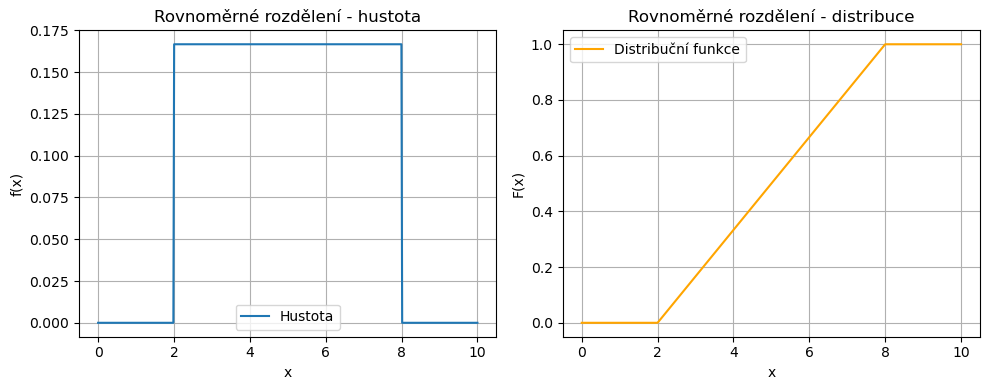

In [2]:

import numpy as np
import matplotlib.pyplot as plt

a, b = 2, 8
x = np.linspace(a-2, b+2, 500)
pdf = np.where((x >= a) & (x <= b), 1/(b-a), 0)
cdf = np.where(x < a, 0, np.where(x > b, 1, (x-a)/(b-a)))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(x, pdf, label='Hustota')
plt.title('Rovnoměrné rozdělení - hustota')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
plt.legend()

plt.subplot(1,2,2)
plt.plot(x, cdf, label='Distribuční funkce', color='orange')
plt.title('Rovnoměrné rozdělení - distribuce')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()


In [3]:

from scipy.stats import uniform

a, b = 2, 8
dist = uniform(loc=a, scale=b-a)

alpha = [0.25, 0.5, 0.75]
kvantily = dist.ppf(alpha)
for i, q in zip(alpha, kvantily):
    print(f"{i}-kvantil: {q}")


0.25-kvantil: 3.5
0.5-kvantil: 5.0
0.75-kvantil: 6.5


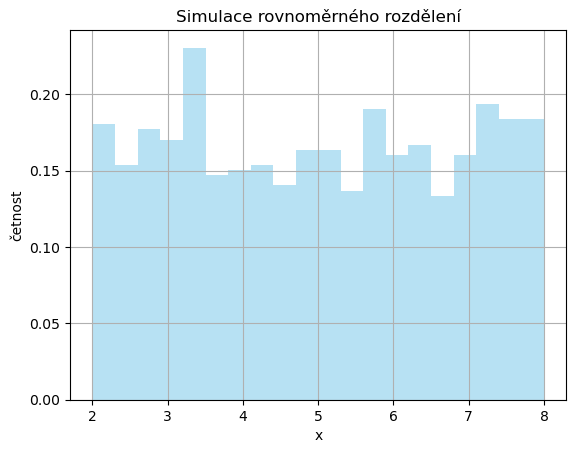

In [4]:

samples = dist.rvs(size=1000)
plt.hist(samples, bins=20, density=True, alpha=0.6, color='skyblue')
plt.title('Simulace rovnoměrného rozdělení')
plt.xlabel('x')
plt.ylabel('četnost')
plt.grid()
plt.show()


**Věta 5.2**: Nechť $X \sim R(0,1)$ a nechť $F$ je spojitá distribuční funkce. Pak náhodná veličina $Y=F^{-1}(X)$ má rozdělení s distribuční funkcí $F.$

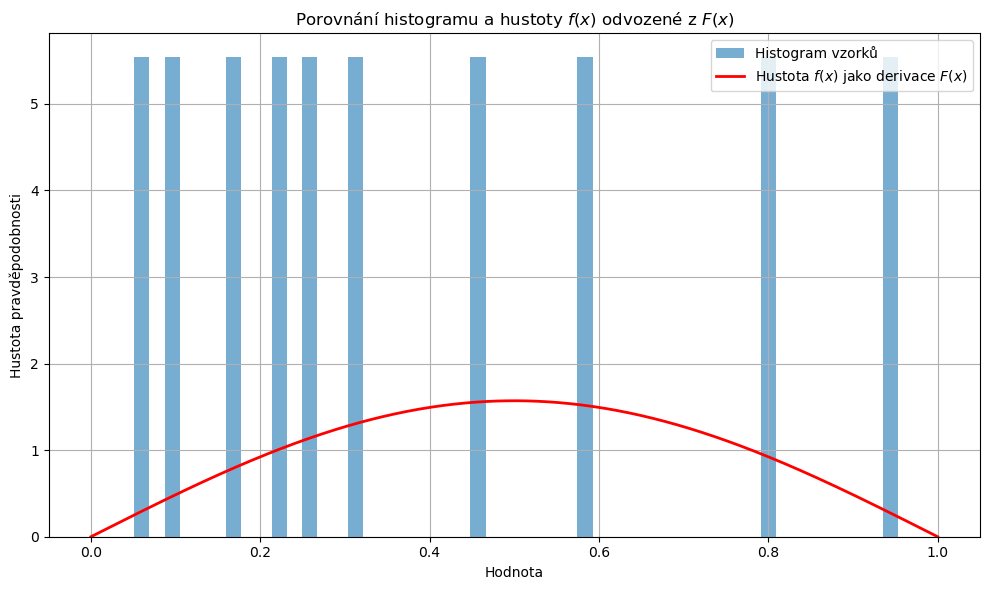

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, diff, lambdify, cos, pi
from scipy.interpolate import interp1d

# 1. Symbolická definice distribuční funkce F_expr
x_sym = symbols('x')
F_expr = 0.5 * (1 - cos(pi * x_sym))  # uživatel může změnit tento výraz

# 2. Funkce hustoty (x) jako derivace F(x)
f_expr = diff(F_expr, x_sym)
f_func = lambdify(x_sym, f_expr, 'numpy')

# 3. Převedení distribuční funkce F(x) na numerickou funkci
F_func = lambdify(x_sym, F_expr, 'numpy')

# 4. Inverzní kvantilová funkce pomocí numerické inverze
x_vals = np.linspace(0, 1, 1000)
F_vals = F_func(x_vals)
F_inv_func = interp1d(F_vals, x_vals, bounds_error=False, fill_value=(x_vals[0], x_vals[-1]))

# 5. Generování náhodných hodnot pomocí inverzní transformace
u_samples = np.random.uniform(0, 1, 10)
x_samples = F_inv_func(u_samples)

# 6. Výpočet hustoty pro porovnání
x_plot = np.linspace(0, 1, 500)
f_vals = f_func(x_plot)

# 7. Vykreslení histogramu a hustoty
plt.figure(figsize=(10, 6))
plt.hist(x_samples, bins=50, density=True, alpha=0.6, label='Histogram vzorků')
plt.plot(x_plot, f_vals, 'r-', lw=2, label='Hustota $f(x)$ jako derivace $F(x)$')
plt.title('Porovnání histogramu a hustoty $f(x)$ odvozené z $F(x)$')
plt.xlabel('Hodnota')
plt.ylabel('Hustota pravděpodobnosti')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("porovnani_histogram_hustota_F_expr.png")
plt.show()

## 5.3 Exponenciální rozdělení
Náhodná veličina $X \sim Exp(\delta)$ má hustotu:
$$f(x) = \begin{cases} \frac{1}{\delta} e^{-x/\delta}, & x \geq 0 \\ 0, & x < 0 \end{cases}$$
Distribuční funkce:
$$F(x) = \begin{cases} 0, & x < 0 \\ 1 - e^{-x/\delta}, & x \geq 0 \end{cases}$$
Střední hodnota: $\mathbb{E}[X] = \delta$
Rozptyl: $\mathrm{D}[X] = \delta^2$

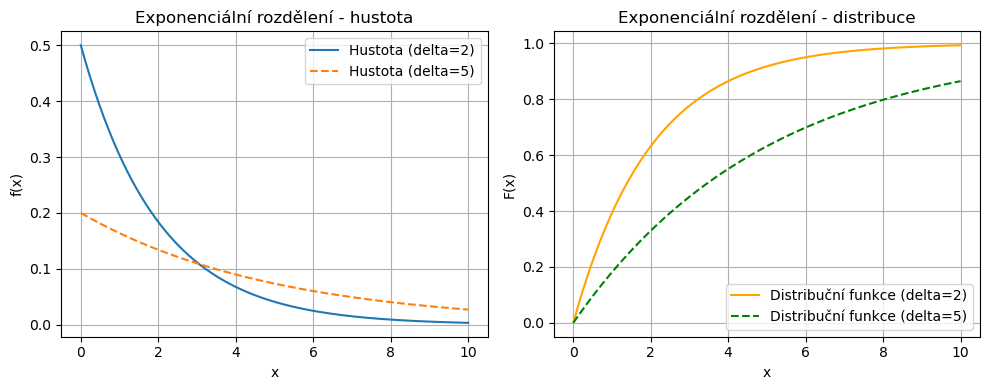

In [6]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
delta = 2
delta2 = 5
x = np.linspace(0, 10, 500)
pdf = stats.expon.pdf(x, scale=delta)
cdf = stats.expon.cdf(x, scale=delta)
pdf2 = stats.expon.pdf(x, scale=delta2)
cdf2 = stats.expon.cdf(x, scale=delta2)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(x, pdf, label='Hustota (delta=2)')
plt.plot(x, pdf2, label='Hustota (delta=5)', linestyle='--')    
plt.title('Exponenciální rozdělení - hustota')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
plt.legend()

plt.subplot(1,2,2)
plt.plot(x, cdf, label='Distribuční funkce (delta=2)', color='orange')
plt.plot(x, cdf2, label='Distribuční funkce (delta=5)', color='green', linestyle='--')
plt.title('Exponenciální rozdělení - distribuce')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()


In [7]:

dist_exp = stats.expon(scale=delta)
alpha = [0.25, 0.5, 0.75]
kvantily_exp = dist_exp.ppf(alpha)
for i, q in zip(alpha, kvantily_exp):
    print(f"{i}-kvantil: {q}")


0.25-kvantil: 0.5753641449035618
0.5-kvantil: 1.3862943611198906
0.75-kvantil: 2.772588722239781


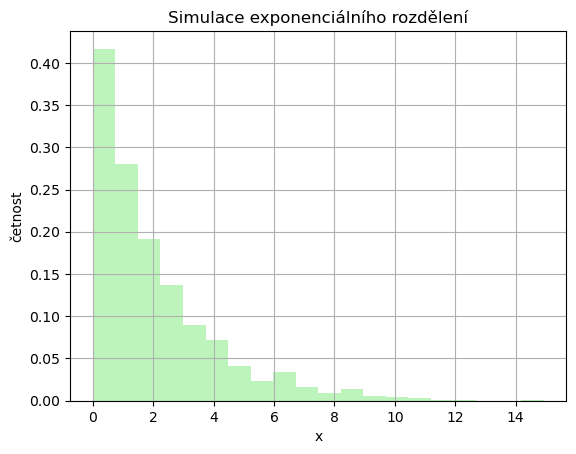

In [8]:

samples_exp = dist_exp.rvs(size=1000)
plt.hist(samples_exp, bins=20, density=True, alpha=0.6, color='lightgreen')
plt.title('Simulace exponenciálního rozdělení')
plt.xlabel('x')
plt.ylabel('četnost')
plt.grid()
plt.show()


**Vlastnosti exponenciálního rozdělení**

Popisuje například dobu čekání na určitou náhodnou událost nebo dobu životnosti součástek, které nepodléhají opotřebení. 

Parametr $\delta$ charakterizuje průměrnou dobu mezi výskytem dvou událostí.Jestliže se počet výskytů událostí během nějakého časového intervalu řídí Poissonovým rozdělením s~parametrem $\lambda$, pak doba mezi výskytem dvou událostí se řídí exponenciálním rozdělením s~parametrem $\delta=\frac{1}{\lambda}.$ 


Rozdělení \uv{nemá paměť} nebo-li $P\left(X > x+y | X > y\right)=P\left(X >x\right)$ \\

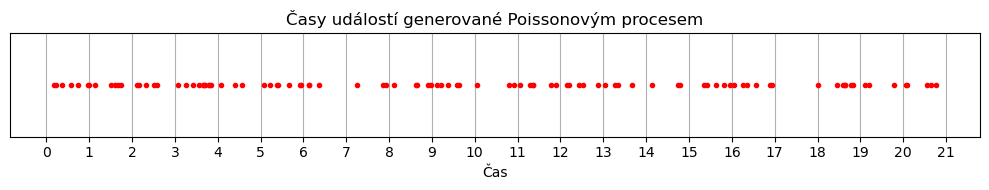

Průměrný počet událostí za jednotku času: 4.762
Průměrná doba mezi událostmi: 0.208
Převrácená hodnota průměrné doby mezi událostmi: 4.810


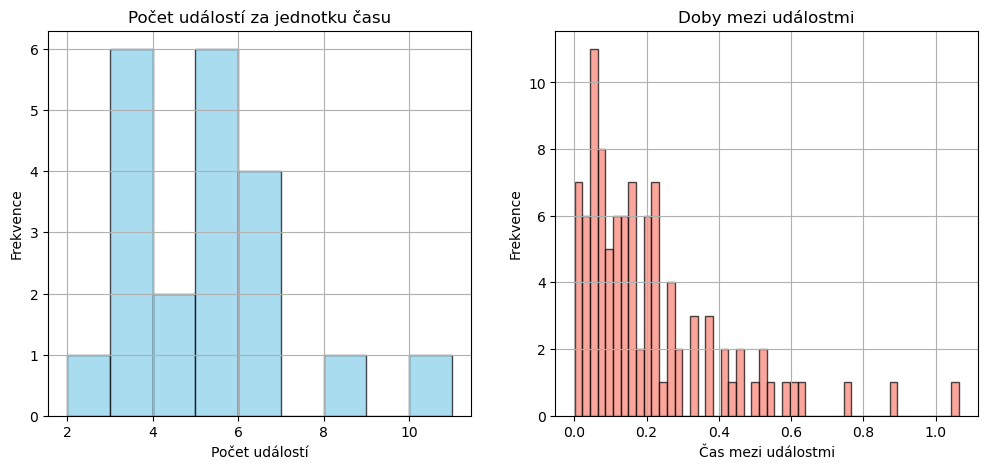

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Parametr Poissonova procesu (intenzita událostí za jednotku času)
lambda_rate = 5  # průměrně 2 události za jednotku času

# 1. Generování časů událostí pomocí exponenciálních mezičasů
n_events = 100
inter_event_times = np.random.exponential(scale=1/lambda_rate, size=n_events)
event_times = np.cumsum(inter_event_times)

# 2. Vykreslení časů událostí jako červené body na časové ose
plt.figure(figsize=(10, 2))
plt.plot(event_times, np.zeros_like(event_times), 'ro', markersize=3)
plt.title('Časy událostí generované Poissonovým procesem')
plt.xlabel('Čas')
plt.yticks([])
# grid podle osy x s krokem 1
plt.xticks(np.arange(0, np.ceil(event_times[-1])+1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Výpočet počtu událostí za jednotku času
max_time = int(np.ceil(event_times[-1]))
counts_per_unit = np.histogram(event_times, bins=max_time)[0]

# 4. Výpočet mezičasů mezi událostmi
inter_event_times_computed = np.diff(event_times)

# 5. Výpočet průměrů
avg_count_per_unit = np.mean(counts_per_unit)
avg_inter_event_time = np.mean(inter_event_times_computed)
inverse_avg_inter_event_time = 1 / avg_inter_event_time

# 6. Vykreslení histogramů
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Histogram počtu událostí za jednotku času
axs[0].hist(counts_per_unit, bins=range(min(counts_per_unit), max(counts_per_unit)+2), alpha=0.7, color='skyblue', edgecolor='black')
axs[0].set_title('Počet událostí za jednotku času')
axs[0].set_xlabel('Počet událostí')
axs[0].set_ylabel('Frekvence')
axs[0].grid(True)

# Histogram mezičasů
axs[1].hist(inter_event_times_computed, bins=50, alpha=0.7, color='salmon', edgecolor='black')
axs[1].set_title('Doby mezi událostmi')
axs[1].set_xlabel('Čas mezi událostmi')
axs[1].set_ylabel('Frekvence')
axs[1].grid(True)

plt.show

# Výpis průměrů pro kontrolu
print(f"Průměrný počet událostí za jednotku času: {avg_count_per_unit:.3f}")
print(f"Průměrná doba mezi událostmi: {avg_inter_event_time:.3f}")
print(f"Převrácená hodnota průměrné doby mezi událostmi: {inverse_avg_inter_event_time:.3f}")

## 5.4 Normální rozdělení

**Značení:** $X \sim \mathcal{N}(\mu, \sigma^2)$  
**Parametry:** $\mu \in \mathbb{R}, \sigma^2 > 0$  
**Nosič:** $X \in \mathbb{R}$

**Funkce hustoty:**  
$$f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x - \mu)^2}{2\sigma^2}}$$

**Distribuční funkce:** nelze vyjádřit elementárními funkcemi

**Střední hodnota:**  
$$\mathbb{E}[X] = \mu$$

**Rozptyl:**  
$$\text{Var}(X) = \sigma^2$$

In [10]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

def plot_normal(mu, sigma):
    x = np.linspace(-5, 5, 500)
    f_std = norm.pdf(x, loc=0, scale=1)
    f_custom = norm.pdf(x, loc=mu, scale=sigma)
    F_std = norm.cdf(x, loc=0, scale=1)
    F_custom = norm.cdf(x, loc=mu, scale=sigma)

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    axs[0].plot(x, f_std, label='Standardní N(0,1)', color='blue')
    axs[0].plot(x, f_custom, label=f'N({mu:.2f}, {sigma:.2f})', color='red')
    axs[0].set_title('Hustota pravděpodobnosti')
    axs[0].set_xlabel('x')
    axs[0].set_ylabel('f(x)')
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(x, F_std, label='Standardní N(0,1)', color='blue')
    axs[1].plot(x, F_custom, label=f'N({mu:.2f}, {sigma:.2f})', color='red')
    axs[1].set_title('Distribuční funkce')
    axs[1].set_xlabel('x')
    axs[1].set_ylabel('F(x)')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

from ipywidgets import interact, FloatSlider
interact(plot_normal,
         mu=FloatSlider(value=0, min=-5, max=5, step=0.1, description='μ'),
         sigma=FloatSlider(value=1, min=0.1, max=5, step=0.1, description='σ'))

interactive(children=(FloatSlider(value=0.0, description='μ', max=5.0, min=-5.0), FloatSlider(value=1.0, descr…

<function __main__.plot_normal(mu, sigma)>

**Pravidlo $3-sigma$**


Pro náhodnou veličinu $X \sim N(\mu;\sigma^2)$
a číslo $k \in \N$ platí
$$
P(\mu - k\sigma < X < \mu + k\sigma) = F(\mu + k\sigma) - F(\mu - k\sigma) = \Phi(k) - \Phi(-k) = 2\Phi(k) - 1
$$
Speciálně s použitím tabulek platí

$P (\mu-\sigma < X < \mu+\sigma)=2\ \Phi (1) -1 \doteq  \frac{2}{3}$

$P (\mu-2\ \sigma < X < \mu+2\ \sigma)=2\ \Phi (2) -1 \doteq  0.95$

$P (\mu-3\ \sigma < X < \mu+3\ \sigma)=2\ \Phi (3) -1 \doteq  0.997$


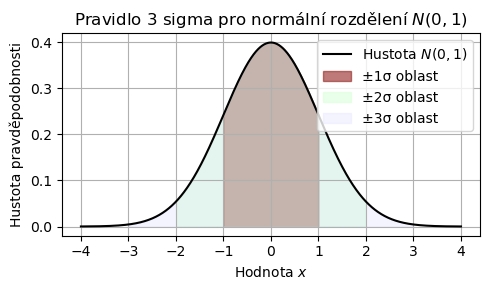

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


# 1. Vykreslení hustoty normálního rozdělení N(0,1) s vyznačením oblastí ±1σ, ±2σ, ±3σ
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)


fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y, label='Hustota $N(0,1)$', color='black')

# Vyplnění oblastí podle pravidla 3 sigma
colors = ["#94221e", '#ccffcc', '#ccccff']
sigmas = [1, 2, 3]
for i, sigma in enumerate(sigmas):
    ax.fill_between(x, y, where=(x >= -sigma) & (x <= sigma), color=colors[i], alpha=0.6-i*0.2,
                    label=f'±{sigma}σ oblast')

ax.set_title('Pravidlo 3 sigma pro normální rozdělení $N(0,1)$')
ax.set_xlabel('Hodnota $x$')
ax.set_ylabel('Hustota pravděpodobnosti')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("pravidlo_3_sigma_interaktivni.png")
plt.show()
